# Logistic Regression – Insurance Prediction

## Objective
The objective of this project is to predict whether a customer will purchase insurance based on their age using Logistic Regression.

## Technologies
- Python
- Pandas
- Matplotlib
- Scikit-learn

In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

## 1. Data Loading and Exploration


In [2]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


## 2. Data Visualization

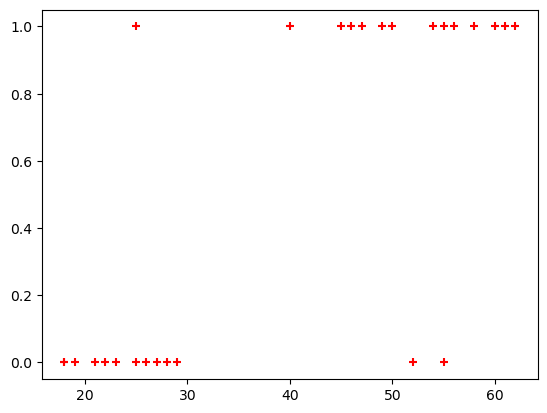

In [3]:
plt.scatter(df.age,df.bought_insurance,color='red',marker='+')

In [4]:
from sklearn.model_selection import train_test_split

## 3. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.2)

In [19]:
X_train

,age
0,22
16,25
4,46
8,62
25,54
5,56
18,19
13,29
21,26
9,61


In [20]:
X_test

,age
12,27
7,60
19,18
10,18
20,21
17,58


In [21]:
y_test

12    0
7     1
19    0
10    0
20    0
17    1
Name: bought_insurance, dtype: int64

In [22]:
y_train

0     0
16    1
4     1
8     1
25    1
5     1
18    0
13    0
21    0
9     1
24    1
1     0
26    0
23    1
2     1
22    1
6     0
14    1
11    0
15    1
3     0
Name: bought_insurance, dtype: int64

## 4. Logistic Regression Model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [24]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
model.coef_

array([[0.11569126]])

In [26]:
model.intercept_

array([-4.38120923])

In [ ]:
## 5. Model Evaluation and Predictions

In [27]:
model.predict(X_test)

array([0, 1, 0, 0, 0, 1], dtype=int64)

In [28]:
y_test

12    0
7     1
19    0
10    0
20    0
17    1
Name: bought_insurance, dtype: int64

In [38]:
model.predict([[36]])

/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [30]:
model.score(X_test,y_test)

1.0

In [39]:
model.predict_proba(X_test)

array([[0.77860322, 0.22139678],
       [0.07173978, 0.92826022],
       [0.90877483, 0.09122517],
       [0.90877483, 0.09122517],
       [0.87563109, 0.12436891],
       [0.08875887, 0.91124113]])

In [41]:
model.predict(X_test)

array([0, 1, 0, 0, 0, 1], dtype=int64)

In [43]:
model.predict([[35]])

/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [46]:
model.predict_proba([[38]])

/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.49623536, 0.50376464]])

## 6. Understanding the Sigmoid Function

Logistic Regression uses the sigmoid function to transform a linear combination of the input features into a probability between 0 and 1.

In [50]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [51]:
def prediction_funcion(age):
    z=0.3131709 * age - 9.91574521
    y_predict=sigmoid(z)
    return y_predict

In [53]:
age=30
prediction_funcion(age)

0.3727076868790119

## Conclusion

This project demonstrates the basic workflow of a binary classification problem using Logistic Regression, from data exploration and model training to probability prediction and interpretation of the sigmoid function.